# 08 - Publication-Ready CD Diagrams

The **Critical Difference (CD) Diagram** is arguably the most powerful visualization for Machine Learning benchmarks. It allows you to see at a glance:
1. The **average rank** of every model across all datasets.
2. The **groups (cliques)** of models that are not statistically different from each other.

In `labicompare`, our CD Diagram implementation includes advanced features like:
- **Bilateral Layout:** Models are split on both sides to prevent text overlap.
- **Maximal Clique Detection:** Thick bars connect models that are statistically tied.
- **Highlighting System:** Make your proposed method stand out with custom colors.

In this tutorial, we will learn how to generate and customize this diagram.

In [2]:
import pandas as pd
import numpy as np
from labicompare.core.data import EvaluationData
from labicompare.stats.posthoc import wilcoxon_holm
from labicompare.plots.ranking import plot_cd_diagram


df = pd.read_csv("./results.csv", index_col="dataset")
eval_data = EvaluationData(df, higher_is_better=True)

# Generate the statistical summary (Required for the diagram)
summary = wilcoxon_holm(eval_data, alpha=0.05)

print(eval_data)
print(summary)

<EvaluationData: 127 datasets, 8 models>
ComparisonSummary(Friedman P-Value=0.0000, H0=REJECTED, Models=8)


## Step 1: Basic CD Diagram

To plot the diagram, you simply need your `EvaluationData` and the `ComparisonSummary`. The function handles all the rank sorting and clique calculations internally.

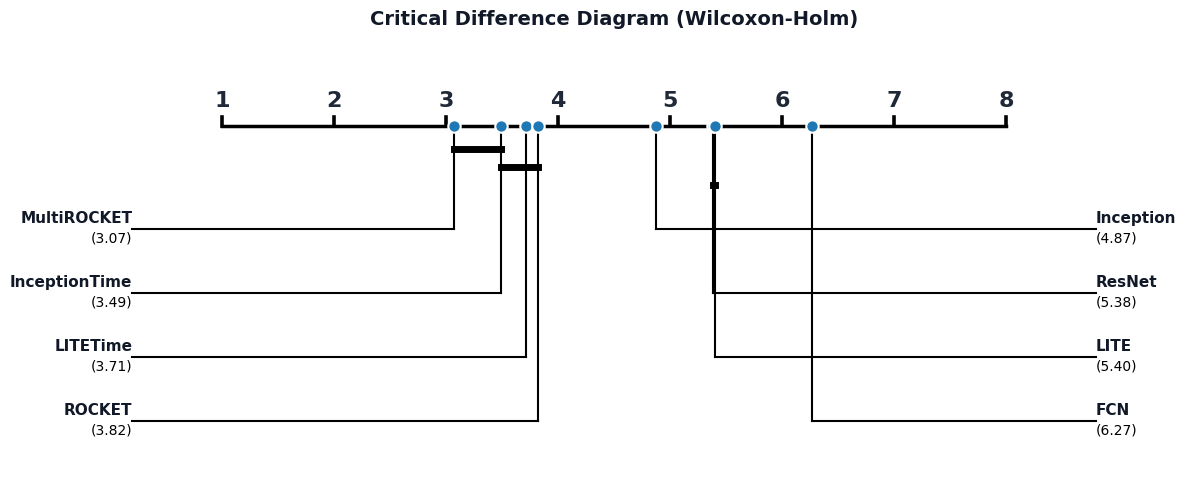

In [3]:
# Standard plot
fig = plot_cd_diagram(
  data=eval_data,
  summary=summary,
)

## Step 2: Highlighting Your Results

When writing a paper, you often want to draw the reviewer's attention to your specific contribution. `labicompare` makes this easy with the `highlight_models` parameter.

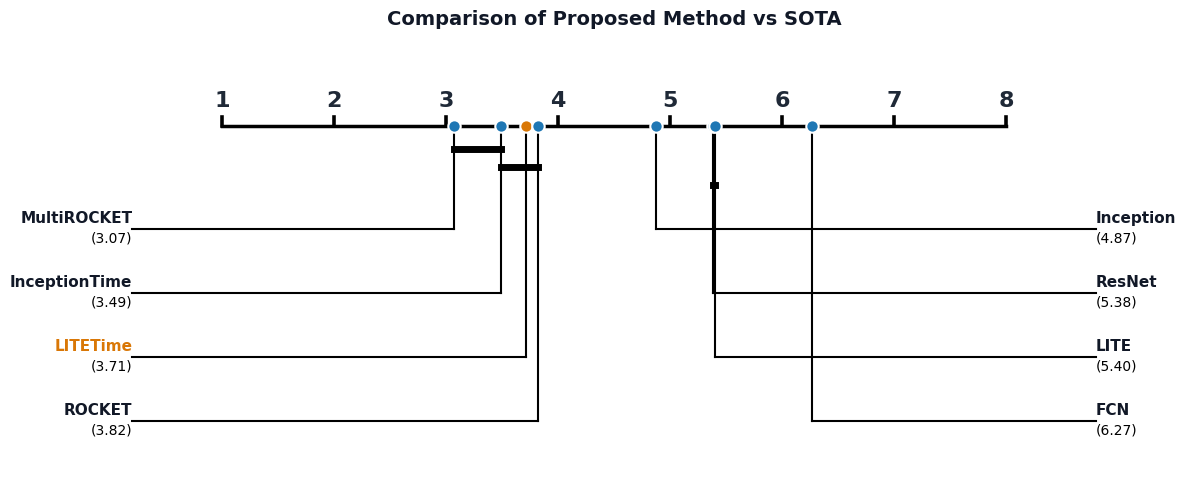

In [ ]:
# Highlighting 'LITETime' in a distinct amber color
fig_highlight = plot_cd_diagram(
  data=eval_data,
  summary=summary,
  highlight_models=['LITETime'],
  highlight_color="#d97706", # Amber/Gold
  title="Comparison of Proposed Method vs SOTA"
)

## How to Interpret the Diagram

- **The Axis:** Represents the average rank. A rank of **1.0** is the best possible (the model was #1 on every dataset).
- **Dots and Labels:** Show the exact average rank of each model.
- **Thick Horizontal Bars:** These are the **Maximal Cliques**. If a group of models is connected by a bar, it means the Wilcoxon-Holm test **failed to find a significant difference** between them. 
- **Example:** In the plot above, if 'MyNewModel' and 'XGBoost' are connected, they are statistically tied.